# Attention from Scratch


 **Scaled Dot-Product Attention** 
 $$\boxed{\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V}$$

 ## Dimensional Analysis of $\text{Attention}(Q, K, V)$

$$Q \in \mathbb{R}^{T \times d_k} \quad K \in \mathbb{R}^{T \times d_k} \quad V \in \mathbb{R}^{T \times d_v}$$

$T$ : sequence length (number of tokens in the sequence)

**Softmax** : Applied along the last dimension (over the $T$ keys for each query)  

**Result: $\mathbb{R}^{T \times d_v}$** : same shape as $V$. Each token is replaced by a weighted sum of the values.

**Remark : in practice with batching**

In practice, inputs have an extra batch dimension $B$ (number of examples processed in parallel):

$$Q \in \mathbb{R}^{B \times T \times d_k} \quad K \in \mathbb{R}^{B \times T \times d_k} \quad V \in \mathbb{R}^{B \times T \times d_v}$$

The computation is identical : PyTorch applies the matrix multiplications independently for each of the $B$ examples. The final output is $\mathbb{R}^{B \times T \times d_v}$. The $B$ dimension does not change the mathematics, only the parallelism.

## Why divide by $\sqrt{d_k}$?

**Assumptions**

The components of $Q$ and $K$ are i.i.d. $\sim \mathcal{N}(0, 1)$.

**Objective**

We want $\forall i, j$:

$$\frac{(QK^\top)_{ij}}{\alpha} \sim \mathcal{N}(0, 1)$$

which is equivalent to finding $\alpha$ such that:

$$\text{Var}\left(\frac{(QK^\top)_{ij}}{\alpha}\right) = 1$$

**Derivation**

By the variance scaling property:

$$\frac{\text{Var}\left((QK^\top)_{ij}\right)}{\alpha^2} = 1 \implies \alpha^2 = \text{Var}\left((QK^\top)_{ij}\right)$$

By the Cauchy matrix multiplication formula:

$$(QK^\top)_{ij} = \sum_{l=1}^{d_k} Q_{il} K_{jl}$$

The terms $Q_{il} K_{jl}$ are independent. For each one:

$$\mathbb{E}[Q_{il} K_{jl}] = \mathbb{E}[Q_{il}]\mathbb{E}[K_{jl}] = 0$$

$$\text{Var}(Q_{il} K_{jl}) = \mathbb{E}[Q_{il}^2]\mathbb{E}[K_{jl}^2] = 1 \times 1 = 1$$

By additivity of variances of independent variables:

$$\text{Var}\left((QK^\top)_{ij}\right) = \sum_{l=1}^{d_k} \text{Var}(Q_{il} K_{jl}) = d_k$$

**Conclusion**

$$\alpha^2 = d_k \implies \alpha = \sqrt{d_k}$$

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device = {device}")

device = cuda


## 2. Scaled Dot-Product Attention


In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q(B,T,dk) K(B,T,dk) V(B,T,dv) mask(B,T,T)
    
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    attn_weights = F.softmax(scores, dim=-1)
    output = attn_weights @ V
    return output, attn_weights

In [3]:
B = 128
T = 10 
d_k = 16
d_v = 16

Q = torch.randn(B, T, d_k)
K = torch.randn(B, T, d_k)
V = torch.randn(B, T, d_v)

output, attn_weights = scaled_dot_product_attention(Q, K, V)
print(output.shape)        
print(attn_weights.shape) 
print(attn_weights[0].sum(dim=-1))  

torch.Size([128, 10, 16])
torch.Size([128, 10, 10])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


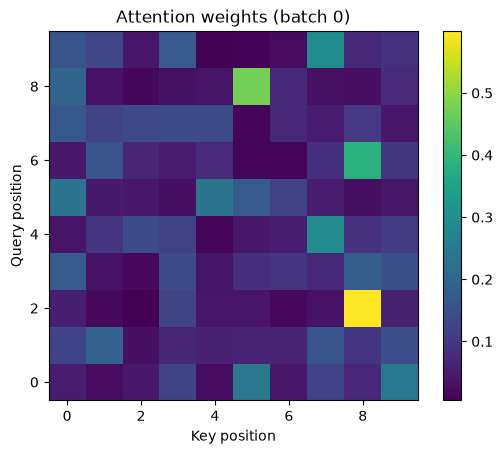

In [4]:
plt.imshow(attn_weights[0].detach(), cmap='viridis', origin="lower")
plt.colorbar()
plt.title('Attention weights (batch 0)')
plt.xlabel('Key position'); plt.ylabel('Query position')
plt.show()

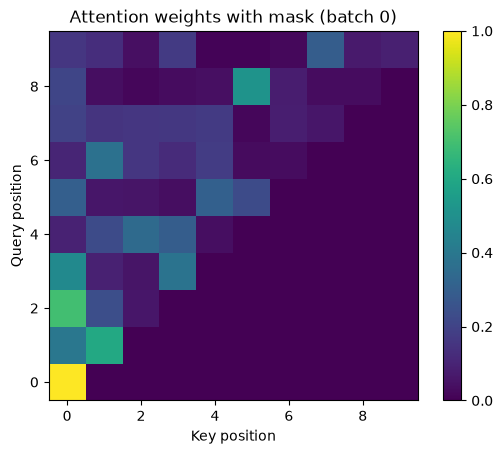

In [5]:
mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)  # upper triangle = True
mask = mask.unsqueeze(0).expand(B, -1, -1)   # (B, T, T)
output_masked, attn_masked = scaled_dot_product_attention(Q, K, V, mask)

plt.imshow(attn_masked[0].detach(), cmap='viridis', origin="lower")
plt.colorbar()
plt.title('Attention weights with mask (batch 0)')
plt.xlabel('Key position'); plt.ylabel('Query position')
plt.show()

## 3. Positional Encoding

**Why it is necessary:** attention is permutation-equivariant : if you shuffle the input tokens, the output is shuffled the same way. Nothing in the attention formula encodes the position of a token in the sequence. Positional encoding fixes this by adding a position-dependent signal to the embeddings before the attention layers.

$$x_\text{input} = \text{Embedding}(token) + PE_{pos}$$


**The sinusoidal formula** :

$$PE_{(pos,\, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_\text{model}}}\right)$$

$$PE_{(pos,\, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_\text{model}}}\right)$$

where $pos$ is the position in the sequence and $i$ is the dimension index.

or example, with $d_\text{model} = 8$ and position $pos$:

$$PE_{pos} = \begin{bmatrix} \sin(\omega_0 \cdot pos) \\ \cos(\omega_0 \cdot pos) \\ \sin(\omega_1 \cdot pos) \\ \cos(\omega_1 \cdot pos) \\ \sin(\omega_2 \cdot pos) \\ \cos(\omega_2 \cdot pos) \\ \sin(\omega_3 \cdot pos) \\ \cos(\omega_3 \cdot pos) \end{bmatrix}$$


### Why Sin and Cos — Linear Representation of Relative Positions

The key property: $PE_{pos+k}$ is a linear function of $PE_{pos}$.

For a pair of dimensions $(2i, 2i+1)$ at frequency $\omega$, using the angle addition formulas:

$$\sin(\omega(pos+k)) = \sin(\omega \cdot pos)\cos(\omega k) + \cos(\omega \cdot pos)\sin(\omega k)$$

$$\cos(\omega(pos+k)) = \cos(\omega \cdot pos)\cos(\omega k) - \sin(\omega \cdot pos)\sin(\omega k)$$

In matrix form:

$$PE_{pos+k} = \underbrace{\begin{bmatrix} \cos(\omega k) & \sin(\omega k) \\ -\sin(\omega k) & \cos(\omega k) \end{bmatrix}}_{M_k} \cdot PE_{pos}$$

$M_k$ is a rotation matrix that depends only on the offset $k$, not on the absolute position $pos$. Moving from position $pos$ to position $pos+k$ is a rotation of angle $\omega k$ in the $(\sin, \cos)$ plane — the same rotation regardless of where you are in the sequence.

This is why the model can easily learn relative positions: "token at distance $k$" = apply $M_k$ to the positional encoding, which is a simple matrix multiplication.

In [6]:
class PositionalEncoding(nn.Module):
    
    def __init__(self, d_model, max_len=5000, dropout=0.1): 
        
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pos = torch.arange(max_len).unsqueeze(1)   #pos(max_len,1)
    
        i = torch.arange(0, d_model, 2)     #i(d_model/2,)
        div_term = torch.exp(i * (-math.log(10000.0) / d_model)) #div_term(d_model/2,)
    
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div_term)   
        pe[:, 1::2] = torch.cos(pos * div_term)    
        pe = pe.unsqueeze(0)                        
        self.register_buffer('pe', pe )

    def forward(self, x):  #x(B,T,d_model)
        T = x.size(1)
        x = x + self.pe[:, :T]   
        return self.dropout(x)
      

In [7]:
d_model = 256 
T = 10
B = 128 
pe = PositionalEncoding(d_model, dropout=0.0) #pe(1,max_len,d_model)
x = torch.zeros(B, T, d_model)
out = pe(x)
print(out.shape)   
# out[0] is now the PE matrix itself (since x=0)

torch.Size([128, 10, 256])


## 4. Multi-Head Attention

Instead of a single attention with $d_\text{model}$-dimensional Q/K/V, project $h$ times into subspaces of dimension $d_k = d_\text{model}/h$, run attention in parallel on each projection, then concatenate and project back:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\, W^O \in \mathbb{R}^{T \times d_\text{model}}$$

For each head $i = 1, \ldots, h$:

$$Q_i = xW^Q_i \quad K_i = xW^K_i \quad V_i = xW^V_i$$

$$\text{head}_i = \text{Attention}(Q_i,\ K_i,\ V_i) \in \mathbb{R}^{T \times d_v}$$

In practice, all $h$ projections are stacked into a single matrix multiplication. The per-head projection matrices are concatenated along the columns:

$$W^Q = (W^Q_1 \mid \cdots \mid W^Q_h) \quad W^K = (W^K_1 \mid \cdots \mid W^K_h) \quad W^V = (W^V_1 \mid \cdots \mid W^V_h)$$

So the full projections become a single matrix multiplication:

$$Q = xW^Q = (Q_1 \mid \cdots \mid Q_h) \quad K = xW^K = (K_1 \mid \cdots \mid K_h) \quad V = xW^V = (V_1 \mid \cdots \mid V_h)$$

then reshaped to separate the heads.

Projection matrices:

$$W^Q_i \in \mathbb{R}^{d_\text{model} \times d_k} \quad W^K_i \in \mathbb{R}^{d_\text{model} \times d_k} \quad W^V_i \in \mathbb{R}^{d_\text{model} \times d_v} \quad W^O \in \mathbb{R}^{d_\text{model} \times d_\text{model}}$$

In the paper: $h = 8$, $d_\text{model} = 512$, $d_k = d_v = 64$.

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        
        super().__init__()
        
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.d_model = d_model

        self.W_Q = nn.Linear(d_model, d_model, bias=False)  
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x_q, x_k, x_v, mask=None):  # x_q, x_k, x_v (B, T, d_model), mask (B, T, T)
       
        B, T, _ = x_q.shape
        
        Q = self.W_Q(x_q)  # Q (B, T, d_model)
        K = self.W_K(x_k)
        V = self.W_V(x_v)

        # Q, K, V : reshape (B, T, d_model) -> (B, T, num_heads, d_k) -> (B, num_heads, T, d_k)
        Q = Q.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
      
        if mask is not None: 
            mask = mask.unsqueeze(1)  # (B, 1, T, T) broadcasts over heads

        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        # attn_output shape: (B, num_heads, T, d_k)
        # attn_weights shape : (B,num_heads, T, T)
    
        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T, self.d_model)

        output = self.W_O(attn_output)

        return output, attn_weights

In [9]:
T = 10 
d_model = 256
num_heads = 8
d_k = d_model // num_heads 

x = torch.randn(B, T, d_model)
mha = MultiHeadAttention(d_model, num_heads)
out, attn = mha(x, x, x)
print(out.shape)   
print(attn.shape) 

torch.Size([128, 10, 256])
torch.Size([128, 8, 10, 10])


## 5. TransformerBlock

One encoder block from the paper (Figure 1, left):

$$x' = \text{LayerNorm}(x + \text{MultiHead}(x, x, x))$$
$$y = \text{LayerNorm}(x' + \text{FFN}(x'))$$

The Feed-Forward Network is two linear layers with ReLU:

$$\text{FFN}(x) = \max(0,\ xW_1 + b_1)W_2 + b_2$$

with inner dimension $d_\text{ff} = 4 \times d_\text{model}$ in the original paper.

**Why $d_\text{ff} > d_\text{model}$?**  In the larger $d_\text{ff}$-dimensional space, the ReLU can selectively activate or deactivate many more directions. Attention aggregates information across tokens; the FFN processes each token individually in this enriched space. In modern LLMs, the FFN is interpreted as an associative memory — the weights $W_1, W_2$ store key-value associations learned during training.

In [10]:
class TransformerBlock(nn.Module):
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
            )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
     
        attn_out, _ = self.attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x
       

In [11]:
d_ff = 4*d_model
block = TransformerBlock(d_model, num_heads, d_ff)
y = block(x)
print(y.shape) 

torch.Size([128, 10, 256])


## 6. TransformerEncoder

Stack $N$ TransformerBlocks. Each block takes the output of the previous one as input. In the original paper $N = 6$.

In [12]:
class TransformerEncoder(nn.Module):
    
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        
        super().__init__()
        self.layers = nn.ModuleList([ 
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
            ])

    def forward(self, x, mask=None):
        
        for layer in self.layers:
            x = layer(x, mask)
            
        return x

In [13]:
num_layers = 6
encoder = TransformerEncoder(d_model, num_heads, d_ff, num_layers)
y = encoder(x)
print(y.shape)   
n_params = sum(p.numel() for p in encoder.parameters())
print("n_params:", n_params)

torch.Size([128, 10, 256])
n_params: 4732416


In [14]:
# Verification of the number of parameters
n_params_th = (4*d_model**2 + (2*(d_ff*d_model)+d_ff+d_model) + 2*2*d_model)*num_layers
# (mha + ffn + layernorm)*6
print(n_params_th)
print(n_params == n_params_th)

4732416
True


## How LayerNorm Works

For each token's vector $x \in \mathbb{R}^{d_\text{model}}$, LayerNorm computes:

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sigma + \epsilon} + \beta$$

where:

$\mu = \frac{1}{d_\text{model}} \sum_{i=1}^{d_\text{model}} x_i$ : mean over the $d_\text{model}$ components

$\sigma = \sqrt{\frac{1}{d_\text{model}} \sum_{i=1}^{d_\text{model}} (x_i - \mu)^2}$ : standard deviation over the components

$\gamma, \beta \in \mathbb{R}^{d_\text{model}}$ : learned parameters (scale and shift), initialized to 1 and 0

$\epsilon \approx 10^{-5}$ : small constant for numerical stability

**Effect:** the mean of each token vector becomes 0 and its standard deviation becomes 1, then $\gamma$ and $\beta$ rescale and shift back. This keeps activations in a stable range across layers.